# Foundations of Neural Graphics and Visual Synthesis
## Lecture 2, Part I — Student PyTorch Tutorial for Google Colab


## Before you begin: Google Colab workflow

This is a **student-facing Google Colab notebook**. No local Python or Visual Studio Code installation is required.

1. Open the notebook in Google Colab.
2. Choose **File → Save a copy in Drive** before editing.
3. Start with the default CPU runtime; the complete notebook is designed to run on CPU.
4. A GPU is optional. To request one, choose **Runtime → Change runtime type → Hardware accelerator → GPU**.
5. Run the notebook from top to bottom. If cells have been executed out of order, choose **Runtime → Restart session and run all**.
6. Save the notebook again before closing the tab or disconnecting the runtime.

The code automatically selects CUDA when it is available and otherwise uses the CPU. Numerical derivative checks use double precision because their purpose is validation rather than peak throughput. The notebook requires only PyTorch, NumPy, and Matplotlib and does not download external datasets.

In [11]:
import math
import platform
import sys
from dataclasses import dataclass
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch

# Reproducible numerical examples.
torch.manual_seed(7)
np.random.seed(7)
torch.set_default_dtype(torch.float64)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
required_torch_func = ("jvp", "vjp", "grad", "vmap", "hessian")
missing_torch_func = [name for name in required_torch_func if not hasattr(torch.func, name)]

print("Python version:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PyTorch version:", torch.__version__)
print("NumPy version:", np.__version__)
print("Selected device:", device)
print("Default dtype:", torch.get_default_dtype())
print("Required torch.func APIs available:", not missing_torch_func)

if missing_torch_func:
    raise RuntimeError(
        "This notebook requires torch.func APIs that are missing from the active Colab runtime: "
        + ", ".join(missing_torch_func)
        + ". Select a current Colab runtime version and restart the session."
    )

Python version: 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
PyTorch version: 2.11.0+cpu
NumPy version: 2.1.3
Selected device: cpu
Default dtype: torch.float64
Required torch.func APIs available: True


In [2]:
def assert_close(a, b, *, rtol=1e-8, atol=1e-10, label='values'):
    # Small validation helper used throughout the tutorial.
    a_t = torch.as_tensor(a)
    b_t = torch.as_tensor(b)
    ok = torch.allclose(a_t, b_t, rtol=rtol, atol=atol)
    err = torch.max(torch.abs(a_t - b_t)).item()
    print(f'{label}:', 'PASS' if ok else 'FAIL', f'(max abs. error={err:.3e})')
    if not ok:
        raise AssertionError(f'{label} differ')


def audit_tensor(name, value, *, semantic_type=None, frame=None, units=None, reduction=None):
    # Report the auditing information emphasized by Slide 7.
    t = torch.as_tensor(value)
    print(f'{name}:')
    print('  shape:', tuple(t.shape))
    print('  dtype:', t.dtype)
    print('  device:', t.device)
    print('  requires_grad:', t.requires_grad)
    if semantic_type is not None:
        print('  semantic type:', semantic_type)
    if frame is not None:
        print('  frame:', frame)
    if units is not None:
        print('  units:', units)
    if reduction is not None:
        print('  reduction:', reduction)


### Section 1: Differentiable-Graphics Overview

In [3]:
# raw parameter -> validity decoder -> renderer -> scalar objective
eta = torch.tensor(.9, device=device, requires_grad=True)
foreground = torch.tensor([0.90, 0.25, 0.10], device=device) #R - 0.9, G - 0.25, B - 0.10)
background = torch.tensor([0.08, 0.12, 0.20], device=device)
target = torch.tensor([0.62, 0.22, 0.15], device=device) # desired RGB color output

alpha = torch.sigmoid(eta)                # decoder g(eta)
prediction = alpha * foreground + (1 - alpha) * background  # renderer R(theta)
loss = 0.5 * torch.sum((prediction - target) ** 2)           # objective L
loss.backward() # computes gradient aka chain rule

print('eta:', eta.item())
print('decoded opacity alpha:', alpha.item())
print('prediction:', prediction.detach().cpu().numpy())
print('loss:', loss.item())
print('dL/deta:', eta.grad.item())

eta: 0.9
decoded opacity alpha: 0.7109495026250039
prediction: [0.66297859 0.21242344 0.12890505]
loss: 0.0011747803210083937
dL/deta: 0.007473427043766365


Text(0.5, 1.0, 'Prediction')

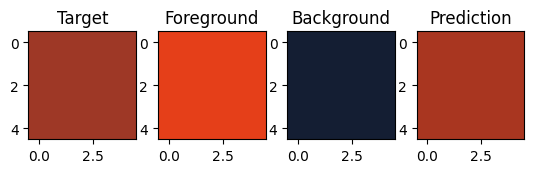

In [4]:
plt.subplot(1,4,1)
image = torch.zeros(5, 5, 3)
image[:, :, :] = target
plt.imshow(image)
plt.title("Target")

plt.subplot(1,4,2)
image = torch.zeros(5, 5, 3)
image[:, :, :] = foreground
plt.imshow(image)
plt.title("Foreground")

plt.subplot(1,4,3)
image = torch.zeros(5, 5, 3)
image[:, :, :] = background
plt.imshow(image)
plt.title("Background")

plt.subplot(1,4,4)
image = torch.zeros(5, 5, 3)
image[:, :, :] = prediction.detach().cpu()
plt.imshow(image)
plt.title("Prediction")

In [5]:
def opacity_renderer(raw_eta):
  alpha = torch.sigmoid(raw_eta) # renderer
  return alpha * foreground + (1 - alpha) * background

# Forward use: eta is known.
known_eta = torch.tensor(-0.4, device=device)
print('Forward prediction:', opacity_renderer(known_eta).cpu().numpy())

# Inverse use: estimate eta from a target image.
est_eta = torch.tensor(0.0, device=device, requires_grad=True)
optimizer = torch.optim.SGD([est_eta], lr=2.0)
for _ in range(20):
    optimizer.zero_grad()
    inverse_loss = torch.mean((opacity_renderer(est_eta) - target) ** 2)
    inverse_loss.backward()
    optimizer.step()
print('Recovered eta:', est_eta.item(), 'inverse loss:', inverse_loss.item())

# Generative use: sample raw parameters and render them.
sampled_eta = torch.randn(4, device=device)
print('Generated opacities:', torch.sigmoid(sampled_eta).cpu().numpy())


Forward prediction: [0.40907612 0.1721706  0.15986877]
Recovered eta: 0.4417659503766829 inverse loss: 0.0008096144796475588
Generated opacities: [0.46336699 0.68700219 0.72047553 0.24706192]


In [6]:
eta = torch.tensor(0.35, device=device, requires_grad=True)
alpha = torch.sigmoid(eta)
image = alpha * foreground + (1 - alpha) * background
loss = 0.5 * torch.sum((image - target) ** 2)
loss.backward()

# Three chain-rule factors.
output_cotangent = image.detach() - target              # 1. loss: dL/dI
renderer_sensitivity = foreground - background          # 2. render sensitivity (opacity): dI/dalpha
decoder_derivative = alpha.detach() * (1 - alpha.detach())  # dalpha/deta
manual = torch.dot(output_cotangent, renderer_sensitivity) * decoder_derivative

print('output factor dL/dI:', output_cotangent.cpu().numpy())
print('renderer factor dI/dalpha:', renderer_sensitivity.cpu().numpy())
print('decoder factor dalpha/deta:', decoder_derivative.item())
print('manual dL/deta:', manual.item())
print('autograd dL/deta:', eta.grad.item())
assert_close(manual, eta.grad, label='three-factor chain rule')


output factor dL/dI: [-0.05897359 -0.02373971 -0.00866176]
renderer factor dI/dalpha: [ 0.82  0.13 -0.1 ]
decoder factor dalpha/deta: 0.2424973950225001
manual dL/deta: -0.012265112557400443
autograd dL/deta: -0.012265112557400445
three-factor chain rule: PASS (max abs. error=1.735e-18)


In [7]:
audit_tensor(
    'eta',
    eta,
    semantic_type='raw scalar parameter',
    frame='parameter space',
    units='logit',
)
audit_tensor(
    'image',
    image,
    semantic_type='RGB prediction',
    frame='image/color space',
    units='linear intensity',
    reduction='none',
)
audit_tensor(
    'loss',
    loss,
    semantic_type='objective',
    frame='scalar',
    units='squared intensity',
    reduction='sum over RGB channels',
)


eta:
  shape: ()
  dtype: torch.float64
  device: cpu
  requires_grad: True
  semantic type: raw scalar parameter
  frame: parameter space
  units: logit
image:
  shape: (3,)
  dtype: torch.float64
  device: cpu
  requires_grad: True
  semantic type: RGB prediction
  frame: image/color space
  units: linear intensity
  reduction: none
loss:
  shape: ()
  dtype: torch.float64
  device: cpu
  requires_grad: True
  semantic type: objective
  frame: scalar
  units: squared intensity
  reduction: sum over RGB channels


### Section 2: Linear algebra and tensor semantics

In [24]:
A = torch.tensor([[2.0, 0.3, 0.0], [0.0, 1.0, 0.2], [0.0, 0.0, 0.7]])
t = torch.tensor([3.0, -2.0, 1.0])
point = torch.tensor([1.0, 2.0, 3.0])
direction = torch.tensor([1.0, 2.0, 3.0])

point_transformed = A @ point + t # matrix mult
direction_transformed = A @ direction
print('point transforms with translation:', point_transformed.numpy())
print('direction ignores translation:', direction_transformed.numpy())


point transforms with translation: [5.6 0.6 3.1]
direction ignores translation: [2.6 2.6 2.1]


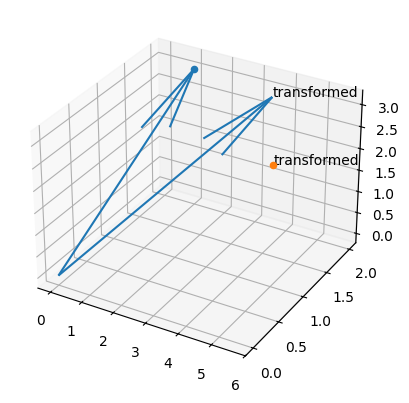

In [42]:
# create 3d setup
fig = plt.figure() 
ax = fig.add_subplot(projection='3d', autoscale_on=True) 
# plot vectors (quiver for tensors)
ax.quiver(0,0,0,direction[0],direction[1],direction[2])
ax.quiver(0,0,0,direction_transformed[0],direction_transformed[1],direction_transformed[2])
ax.text(direction_transformed[0],direction_transformed[1],direction_transformed[2], "transformed")

# plot point (scatter for points non tensors)
ax.scatter(point[0], point[1], point[2])
ax.scatter(point_transformed[0], point_transformed[1], point_transformed[2])
ax.text(point_transformed[0], point_transformed[1], point_transformed[2], "transformed")
plt.show()

In [10]:
tangent_1 = torch.tensor([1.0, 0.0, 0.0])
tangent_2 = torch.tensor([0.0, 1.0, 0.0])
normal = torch.cross(tangent_1, tangent_2, dim=0)

transformed_tangent_1 = A @ tangent_1
transformed_tangent_2 = A @ tangent_2
transformed_normal = torch.linalg.inv(A).T @ normal

print('n dot v1 before:', torch.dot(normal, tangent_1).item())
print('n dot v2 before:', torch.dot(normal, tangent_2).item())
print("n' dot v1' after:", torch.dot(transformed_normal, transformed_tangent_1).item())
print("n' dot v2' after:", torch.dot(transformed_normal, transformed_tangent_2).item())


n dot v1 before: 0.0
n dot v2 before: 0.0
n' dot v1' after: 0.0
n' dot v2' after: 0.0


In [43]:
x = torch.tensor([1.5, -0.5, 2.0], requires_grad=True)
unit = x / torch.linalg.norm(x)
J_autograd = torch.autograd.functional.jacobian(lambda z: z / torch.linalg.norm(z), x)
I = torch.eye(3)
J_formula = (I - torch.outer(unit.detach(), unit.detach())) / torch.linalg.norm(x.detach())
print('normalized vector:', unit.detach().numpy())
assert_close(J_autograd, J_formula, label='normalization Jacobian')
print('J x (radial direction should vanish):', (J_formula @ x.detach()).numpy())


normalized vector: [ 0.58834841 -0.19611614  0.78446454]
normalization Jacobian: PASS (max abs. error=0.000e+00)
J x (radial direction should vanish): [-1.11022302e-16  1.38777878e-17 -1.11022302e-16]


In [44]:
a = torch.tensor([2.0, 1.0, -1.0])
b = torch.tensor([1.0, 3.0, 2.0])
dot = torch.dot(a, b)
angle = torch.acos(dot / (torch.linalg.norm(a) * torch.linalg.norm(b)))
print('a dot b:', dot.item())
print('||a||:', torch.linalg.norm(a).item())
print('angle in degrees:', torch.rad2deg(angle).item())


a dot b: 3.0
||a||: 2.449489742783178
angle in degrees: 70.89339464913091


In [45]:
a = torch.tensor([3.0, 2.0])
b = torch.tensor([2.0, 1.0])
projection = (torch.dot(a, b) / torch.dot(b, b)) * b
rejection = a - projection
print('projection:', projection.numpy())
print('rejection:', rejection.numpy())
print('orthogonality b^T r:', torch.dot(b, rejection).item())
assert_close(a, projection + rejection, label='projection + rejection')


projection: [3.2 1.6]
rejection: [-0.2  0.4]
orthogonality b^T r: -4.440892098500626e-16
projection + rejection: PASS (max abs. error=0.000e+00)


In [46]:
b_hat = b / torch.linalg.norm(b)
P_b = torch.outer(b_hat, b_hat)
batch = torch.tensor([[3.0, 2.0], [-1.0, 4.0], [0.5, -2.0]])
projected_batch = batch @ P_b.T
print('projector P_b:\n', P_b.numpy())
print('projected batch:\n', projected_batch.numpy())


projector P_b:
 [[0.8 0.4]
 [0.4 0.2]]
projected batch:
 [[ 3.2  1.6]
 [ 0.8  0.4]
 [-0.4 -0.2]]


In [47]:
print('symmetry error:', torch.linalg.norm(P_b.T - P_b).item())
print('idempotence error:', torch.linalg.norm(P_b @ P_b - P_b).item())
print('subspace preservation error:', torch.linalg.norm(P_b @ b - b).item())
print('residual orthogonality:', torch.dot(b, a - P_b @ a).item())


symmetry error: 0.0
idempotence error: 1.3877787807814457e-16
subspace preservation error: 2.482534153247273e-16
residual orthogonality: 6.661338147750939e-16


In [48]:
# Exercise 1 workspace
B_ex = torch.tensor([[1.0, 0.0], [1.0, 1.0], [0.0, 1.0]])
x_ex = torch.tensor([2.0, -1.0, 3.0])
# TODO: compute P_ex and the four audits.


In [49]:
P_ex = B_ex @ torch.linalg.inv(B_ex.T @ B_ex) @ B_ex.T
r_ex = x_ex - P_ex @ x_ex
print('symmetry:', torch.linalg.norm(P_ex.T - P_ex).item())
print('idempotence:', torch.linalg.norm(P_ex @ P_ex - P_ex).item())
print('preservation:', torch.linalg.norm(P_ex @ B_ex - B_ex).item())
print('residual orthogonality:', torch.linalg.norm(B_ex.T @ r_ex).item())


symmetry: 0.0
idempotence: 0.0
preservation: 0.0
residual orthogonality: 0.0


In [50]:
A_ls = torch.tensor([[1.0, 0.0], [1.0, 1.0], [1.0, 2.0], [1.0, 3.0]])
y_ls = torch.tensor([1.0, 2.0, 2.0, 4.0])
solution = torch.linalg.lstsq(A_ls, y_ls).solution
prediction = A_ls @ solution
residual = y_ls - prediction
print('least-squares parameters:', solution.numpy())
print('residual:', residual.numpy())
print('A^T r:', (A_ls.T @ residual).numpy())


least-squares parameters: [0.9 0.9]
residual: [ 0.1  0.2 -0.7  0.4]
A^T r: [ 1.11022302e-16 -4.44089210e-16]


In [51]:
weights = torch.tensor([1.0, 1.0, 0.2, 1.0])
W = torch.diag(weights)
lam = 0.5
normal_matrix = A_ls.T @ W @ A_ls + lam * torch.eye(2)
rhs = A_ls.T @ W @ y_ls
ridge_solution = torch.linalg.solve(normal_matrix, rhs)
print('weighted ridge solution:', ridge_solution.numpy())


weighted ridge solution: [0.82405345 0.98886414]


In [52]:
# Compare normal equations with a stable least-squares solve on a nearly collinear design.
xgrid = torch.linspace(0, 1, 20)
A_bad = torch.stack([torch.ones_like(xgrid), xgrid, xgrid + 1e-7 * xgrid**2], dim=1)
y_bad = 1 + 2 * xgrid
normal_solution = torch.linalg.solve(A_bad.T @ A_bad, A_bad.T @ y_bad)
lstsq_solution = torch.linalg.lstsq(A_bad, y_bad).solution
print('normal equations:', normal_solution.numpy())
print('lstsq/QR-like driver:', lstsq_solution.numpy())
print('condition number A:', torch.linalg.cond(A_bad).item())
print('condition number A^T A:', torch.linalg.cond(A_bad.T @ A_bad).item())


normal equations: [ 1.00000003 -0.06830317  2.06830296]
lstsq/QR-like driver: [1.00000000e+00 1.99999999e+00 7.69010323e-09]
condition number A: 215678644.55484205
condition number A^T A: 3.5055156912066772e+16


In [53]:
U, S, Vh = torch.linalg.svd(A_bad, full_matrices=False)
print('singular values:', S.numpy())
print('right singular vectors (rows of V^T):\n', Vh.numpy())
print('numerical rank:', torch.linalg.matrix_rank(A_bad).item())


singular values: [5.59754652e+00 1.53352029e+00 2.59531793e-08]
right singular vectors (rows of V^T):
 [[-7.80362022e-01 -4.42173657e-01 -4.42173689e-01]
 [ 6.25328005e-01 -5.51799245e-01 -5.51799310e-01]
 [-1.11648434e-08  7.07106817e-01 -7.07106746e-01]]
numerical rank: 3


In [54]:
# Perturb the observation and compare parameter sensitivity.
delta_y = 1e-6 * torch.randn_like(y_bad)
sol_1 = torch.linalg.lstsq(A_bad, y_bad).solution
sol_2 = torch.linalg.lstsq(A_bad, y_bad + delta_y).solution
print(
    'relative data perturbation:',
    (torch.linalg.norm(delta_y) / torch.linalg.norm(y_bad)).item(),
)
print(
    'relative parameter perturbation:',
    (torch.linalg.norm(sol_2 - sol_1) / torch.linalg.norm(sol_1)).item(),
)


relative data perturbation: 6.242904107740227e-07
relative parameter perturbation: 14.743812551893193


In [55]:
def truncated_pinv(A, relative_threshold=1e-5):
    U, S, Vh = torch.linalg.svd(A, full_matrices=False)
    keep = S > relative_threshold * S.max()
    Sinv = torch.where(keep, 1 / S, torch.zeros_like(S))
    return Vh.T @ torch.diag(Sinv) @ U.T, keep

A_pinv, keep = truncated_pinv(A_bad, relative_threshold=1e-5)
truncated_solution = A_pinv @ y_bad
print('retained singular directions:', keep.numpy())
print('truncated-SVD solution:', truncated_solution.numpy())


retained singular directions: [ True  True False]
truncated-SVD solution: [1.00000002 0.99999991 0.99999999]


In [56]:
def nonlinear_renderer(theta):
    # A compact nonlinear forward model with two parameters and three observations.
    return torch.stack([
        torch.sin(theta[0]) + theta[1] ** 2,
        theta[0] * theta[1],
        torch.exp(-theta[0]) + theta[1],
    ])

theta0 = torch.tensor([0.4, -0.2])
delta = torch.tensor([1e-3, -2e-3])
J = torch.autograd.functional.jacobian(nonlinear_renderer, theta0)
linearized = nonlinear_renderer(theta0) + J @ delta
exact = nonlinear_renderer(theta0 + delta)
print('Jacobian:\n', J.numpy())
assert_close(linearized, exact, rtol=1e-5, atol=1e-5, label='local linearization')


Jacobian:
 [[ 0.92106099 -0.4       ]
 [-0.2         0.4       ]
 [-0.67032005  1.        ]]
local linearization: PASS (max abs. error=3.805e-06)


In [57]:
# Batched alpha compositing: batch x samples and batch x samples x RGB.
weights = torch.tensor([[0.2, 0.3, 0.5], [0.6, 0.1, 0.3]])
rgb = torch.tensor([
    [[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]],
    [[0.8, 0.2, 0.1], [0.1, 0.7, 0.2], [0.2, 0.1, 0.9]],
])
composite = torch.einsum('bs,bsc->bc', weights, rgb)
print('composited colors:\n', composite.numpy())


composited colors:
 [[0.2  0.3  0.5 ]
 [0.55 0.22 0.35]]


In [58]:
weights_explicit = weights[..., None]
composite_broadcast = (weights_explicit * rgb).sum(dim=1)
assert_close(composite_broadcast, composite, label='broadcasted composite')
print('weights shape:', tuple(weights.shape))
print('expanded weights shape:', tuple(weights_explicit.shape))
print('RGB shape:', tuple(rgb.shape))
print('reduction axis: samples (dim=1)')


broadcasted composite: PASS (max abs. error=0.000e+00)
weights shape: (2, 3)
expanded weights shape: (2, 3, 1)
RGB shape: (2, 3, 3)
reduction axis: samples (dim=1)


In [59]:
# Exercise 2 workspace
def composite_shape_safe(weights, rgb):
    # TODO: add checks and implement the reduction.
    raise NotImplementedError


In [60]:
def composite_shape_safe(weights, rgb):
    assert weights.ndim == 2
    assert rgb.ndim == 3
    assert weights.shape == rgb.shape[:2]
    assert rgb.shape[-1] == 3
    return (weights[..., None] * rgb).sum(dim=1)

assert_close(composite_shape_safe(weights, rgb), composite, label='shape-safe compositing')


shape-safe compositing: PASS (max abs. error=0.000e+00)


In [61]:
A_var = torch.randn(5, 3, requires_grad=True)
x_var = torch.randn(3)
b_var = torch.randn(5)
residual = A_var @ x_var - b_var
loss = 0.5 * torch.dot(residual, residual)
loss.backward()
manual_grad = torch.outer(residual.detach(), x_var)
assert_close(A_var.grad, manual_grad, label='matrix differential gradient dL/dA')


matrix differential gradient dL/dA: PASS (max abs. error=0.000e+00)


### Section 3: Transformations and camera geometry

In [62]:
def homogenize_point(p):
    return torch.cat([p, torch.ones(1, dtype=p.dtype)])

def homogenize_direction(v):
    return torch.cat([v, torch.zeros(1, dtype=v.dtype)])

T = torch.eye(4)
T[:3, :3] = A
T[:3, 3] = t
p_h = homogenize_point(point)
v_h = homogenize_direction(direction)
print('homogeneous point result:', (T @ p_h).numpy())
print('homogeneous direction result:', (T @ v_h).numpy())


homogeneous point result: [5.6 0.6 3.1 1. ]
homogeneous direction result: [2.6 2.6 2.1 0. ]


In [63]:
def rotation_z(angle):
    c, s = torch.cos(angle), torch.sin(angle)
    return torch.stack([
        torch.stack([c, -s, torch.tensor(0.0)]),
        torch.stack([s,  c, torch.tensor(0.0)]),
        torch.tensor([0.0, 0.0, 1.0]),
    ])

S_scale = torch.diag(torch.tensor([2.0, 1.0, 1.0, 1.0]))
R4 = torch.eye(4); R4[:3, :3] = rotation_z(torch.tensor(math.pi / 2))
Tr = torch.eye(4); Tr[:3, 3] = torch.tensor([1.0, 0.0, 0.0])
q = torch.tensor([1.0, 0.0, 0.0, 1.0])
print('translate @ rotate @ scale:', (Tr @ R4 @ S_scale @ q).numpy())
print('scale @ rotate @ translate:', (S_scale @ R4 @ Tr @ q).numpy())


translate @ rotate @ scale: [1. 2. 0. 1.]
scale @ rotate @ translate: [2.4492936e-16 2.0000000e+00 0.0000000e+00 1.0000000e+00]


In [64]:
T_inv = torch.linalg.inv(T)
recovered_point = T_inv @ (T @ p_h)
normal_h = torch.cat([normal, torch.zeros(1)])
normal_matrix = torch.linalg.inv(T).T
print('point recovered by inverse:', recovered_point.numpy())
print('normal transformed by inverse-transpose:', (normal_matrix @ normal_h).numpy())


point recovered by inverse: [1. 2. 3. 1.]
normal transformed by inverse-transpose: [ 0.          0.          1.42857143 -1.42857143]


In [65]:
def skew(w):
    wx, wy, wz = w
    return torch.stack([
        torch.stack([torch.tensor(0.0), -wz, wy]),
        torch.stack([wz, torch.tensor(0.0), -wx]),
        torch.stack([-wy, wx, torch.tensor(0.0)]),
    ])

def rodrigues(w):
    theta = torch.linalg.norm(w)
    if theta.item() < 1e-12:
        return torch.eye(3) + skew(w)
    K = skew(w / theta)
    return torch.eye(3) + torch.sin(theta) * K + (1 - torch.cos(theta)) * (K @ K)

w = torch.tensor([0.2, -0.1, 0.05])
R = rodrigues(w)
T_se3 = torch.eye(4)
T_se3[:3, :3] = R
T_se3[:3, 3] = torch.tensor([0.5, -0.2, 1.0])
print('R^T R error:', torch.linalg.norm(R.T @ R - torch.eye(3)).item())
print('det(R):', torch.linalg.det(R).item())
print('SE(3) matrix:\n', T_se3.numpy())


R^T R error: 1.6488649016257693e-16
det(R): 1.0
SE(3) matrix:
 [[ 0.9937773  -0.05951997 -0.09414913  0.5       ]
 [ 0.03960732  0.97884281 -0.20074367 -0.2       ]
 [ 0.10410546  0.19576551  0.97510918  1.        ]
 [ 0.          0.          0.          1.        ]]


In [66]:
def quat_to_matrix(q):
    q = q / torch.linalg.norm(q)
    w, x, y, z = q
    return torch.stack([
        torch.stack([1 - 2*(y*y + z*z), 2*(x*y - z*w), 2*(x*z + y*w)]),
        torch.stack([2*(x*y + z*w), 1 - 2*(x*x + z*z), 2*(y*z - x*w)]),
        torch.stack([2*(x*z - y*w), 2*(y*z + x*w), 1 - 2*(x*x + y*y)]),
    ])

q_raw = torch.tensor([0.9, 0.2, -0.1, 0.3])
R_q = quat_to_matrix(q_raw)
R_axis_angle = rodrigues(torch.tensor([0.2, -0.1, 0.3]))
print('quaternion rotation determinant:', torch.linalg.det(R_q).item())
print('axis-angle rotation determinant:', torch.linalg.det(R_axis_angle).item())


quaternion rotation determinant: 1.0
axis-angle rotation determinant: 0.9999999999999999


In [67]:
point_camera = torch.tensor([1.2, -0.4, 3.0])
delta_twist = torch.tensor([1e-3, -2e-3, 1e-3, 2e-3, 0.5e-3, -1e-3])
delta_t = delta_twist[:3]
delta_w = delta_twist[3:]
first_order = point_camera + delta_t - skew(point_camera) @ delta_w
exact = rodrigues(delta_w) @ point_camera + delta_t
print('first-order pose update:', first_order.numpy())
print('exact small pose update:', exact.numpy())
print('approximation error:', torch.linalg.norm(first_order - exact).item())


first-order pose update: [ 1.2021 -0.4092  2.9996]
exact small pose update: [ 1.20209605 -0.40919914  2.99959253]
approximation error: 8.497093853039515e-06


In [68]:
q = torch.tensor([0.8, 0.2, -0.3, 0.4])
q_normalized = q / torch.linalg.norm(q)
R_plus = quat_to_matrix(q_normalized)
R_minus = quat_to_matrix(-q_normalized)
print('normalized quaternion:', q_normalized.numpy())
assert_close(R_plus, R_minus, label='q and -q rotation equivalence')


normalized quaternion: [ 0.82956136  0.20739034 -0.31108551  0.41478068]
q and -q rotation equivalence: PASS (max abs. error=0.000e+00)


In [75]:
def project_point(P_world, R_wc, t_wc, fx, fy, cx, cy):
    P_camera = R_wc @ P_world + t_wc
    X, Y, Z = P_camera
    pixel = torch.stack([fx * X / Z + cx, fy * Y / Z + cy])
    return pixel, P_camera

P_world = torch.tensor([1.0, 0.5, 4.0])
R_wc = rodrigues(torch.tensor([0.05, -0.02, 0.01]))
t_wc = torch.tensor([0.1, -0.2, 0.3])
pixel, P_camera = project_point(P_world, R_wc, t_wc, 800.0, 820.0, 320.0, 240.0)
print('camera point:', P_camera.numpy())
print('pixel:', pixel.numpy())


camera point: [1.01554237 0.10854537 4.3393789 ]
pixel: [507.22354351 260.51150822]


In [76]:
camera_center_world = -R_wc.T @ t_wc
print('camera center in world coordinates:', camera_center_world.numpy())
print('world-to-camera of camera center:', (R_wc @ camera_center_world + t_wc).numpy())


camera center in world coordinates: [-0.10414796  0.18582704 -0.3076061 ]
world-to-camera of camera center: [0. 0. 0.]


In [77]:
def perspective(camera_point, fx=800.0, fy=820.0, cx=320.0, cy=240.0):
    X, Y, Z = camera_point
    return torch.stack([fx * X / Z + cx, fy * Y / Z + cy])

camera_point = torch.tensor([1.1, -0.4, 3.2], requires_grad=True)
J_auto = torch.autograd.functional.jacobian(perspective, camera_point)
X, Y, Z = camera_point.detach()
J_formula = torch.tensor([
    [800.0 / Z, 0.0, -800.0 * X / Z**2],
    [0.0, 820.0 / Z, -820.0 * Y / Z**2],
])
print('projection Jacobian:\n', J_formula.numpy())
assert_close(J_auto, J_formula, label='analytical camera Jacobian')


projection Jacobian:
 [[250.        0.      -85.9375 ]
 [  0.      256.25     32.03125]]
analytical camera Jacobian: PASS (max abs. error=7.105e-15)


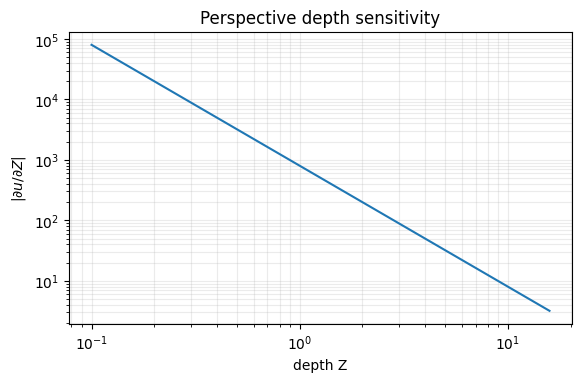

In [78]:
depths = torch.logspace(-1, 1.2, 120)
X = torch.tensor(1.0)
sensitivity = 800.0 * torch.abs(X) / depths**2
plt.figure(figsize=(6.5, 3.8))
plt.loglog(depths.numpy(), sensitivity.numpy())
plt.xlabel('depth Z')
plt.ylabel(r'$|\partial u / \partial Z|$')
plt.title('Perspective depth sensitivity')
plt.grid(True, which='both', alpha=0.25)
plt.show()


In [79]:
def backproject_pixel(pixel, fx=800.0, fy=820.0, cx=320.0, cy=240.0):
    u, v = pixel
    direction = torch.stack([(u - cx) / fx, (v - cy) / fy, torch.tensor(1.0)])
    return direction / torch.linalg.norm(direction)

ray_camera = backproject_pixel(pixel)
ray_world = R_wc.T @ ray_camera
print('camera-space ray:', ray_camera.numpy())
print('world-space ray:', ray_world.numpy())


camera-space ray: [0.22780479 0.02434872 0.97340234]
world-space ray: [0.24768066 0.07047476 0.96627512]


In [80]:
@dataclass(frozen=True)
class FramedTransform:
    matrix: torch.Tensor
    source: str
    target: str

    def compose(self, other: 'FramedTransform') -> 'FramedTransform':
        if other.target != self.source:
            raise ValueError(f'frame mismatch: {other.target} != {self.source}')
        return FramedTransform(self.matrix @ other.matrix, other.source, self.target)

T_world_camera = FramedTransform(T_se3, 'world', 'camera')
T_object_world = FramedTransform(torch.eye(4), 'object', 'world')
T_object_camera = T_world_camera.compose(T_object_world)
print('valid composition:', T_object_camera.source, '->', T_object_camera.target)


valid composition: object -> camera


In [81]:
Xc = torch.tensor([1.1, -0.4, 3.2])
J_proj = torch.tensor([
    [800.0 / Xc[2], 0.0, -800.0 * Xc[0] / Xc[2]**2],
    [0.0, 820.0 / Xc[2], -820.0 * Xc[1] / Xc[2]**2],
])
J_point_twist = torch.cat([torch.eye(3), -skew(Xc)], dim=1)
J_pixel_twist = J_proj @ J_point_twist
print('2x6 pixel Jacobian with respect to a local twist:\n', J_pixel_twist.numpy())


2x6 pixel Jacobian with respect to a local twist:
 [[ 250.          0.        -85.9375     34.375     894.53125   100.      ]
 [   0.        256.25       32.03125  -832.8125    -35.234375  281.875   ]]


### Section 4: Differential calculus and automatic differentiation

In [82]:
def scalar_program(x):
    return torch.sin(x) * torch.exp(-0.2 * x**2)

x0 = torch.tensor(0.7, requires_grad=True)
y0 = scalar_program(x0)
y0.backward()
autodiff = x0.grad.item()
for eps in [1e-2, 1e-4, 1e-6]:
    finite_difference = (
        (
            scalar_program(torch.tensor(0.7 + eps))
            - scalar_program(torch.tensor(0.7 - eps))
        )
        / (2 * eps)
    ).item()
    print(
        f'epsilon={eps:.0e}: finite difference={finite_difference:.10f}, '
        f'autodiff={autodiff:.10f}'
    )


epsilon=1e-02: finite difference=0.5298896643, autodiff=0.5299011379
epsilon=1e-04: finite difference=0.5299011367, autodiff=0.5299011379
epsilon=1e-06: finite difference=0.5299011379, autodiff=0.5299011379


In [83]:
x = torch.tensor(0.7, requires_grad=True)
a = x**2
b = torch.sin(a)
c = a * b
print('x.is_leaf:', x.is_leaf, 'x.grad_fn:', x.grad_fn)
print('a.is_leaf:', a.is_leaf, 'a.grad_fn:', type(a.grad_fn).__name__)
print('b.grad_fn:', type(b.grad_fn).__name__)
print('c.grad_fn:', type(c.grad_fn).__name__)


x.is_leaf: True x.grad_fn: None
a.is_leaf: False a.grad_fn: PowBackward0
b.grad_fn: SinBackward0
c.grad_fn: MulBackward0


In [84]:
x = torch.tensor(0.7, requires_grad=True)
a = x**2
b = torch.sin(a)
c = a * b
L = 0.5 * (c - 0.4)**2
print(
    'forward primals:',
    {'x': x.item(), 'a': a.item(), 'b': b.item(), 'c': c.item(), 'L': L.item()},
)
L.backward()
print('reverse result dL/dx:', x.grad.item())


forward primals: {'x': 0.7, 'a': 0.48999999999999994, 'b': 0.47062588817115797, 'c': 0.23060668520386737, 'L': 0.014347047548810846}
reverse result dL/dx: -0.21413967426069297


In [85]:
def f_local(z):
    return torch.stack([torch.sin(z[0]) + z[1]**2, z[0] * z[1]])

z0 = torch.tensor([0.4, -0.3])
dz = torch.tensor([1e-4, -2e-4])
J = torch.autograd.functional.jacobian(f_local, z0)
local_prediction = f_local(z0) + J @ dz
exact = f_local(z0 + dz)
print('Jacobian:\n', J.numpy())
assert_close(local_prediction, exact, rtol=1e-6, atol=1e-7, label='local linear map')


Jacobian:
 [[ 0.92106099 -0.6       ]
 [-0.3         0.4       ]]
local linear map: PASS (max abs. error=3.805e-08)


In [86]:
from torch.func import jvp, vjp, grad, vmap

z0 = torch.tensor([0.4, -0.3])
v = torch.tensor([1.0, 2.0])
primal_out, tangent_out = jvp(f_local, (z0,), (v,))
print('f(z0):', primal_out.numpy())
print('J v:', tangent_out.numpy())
assert_close(tangent_out, J @ v, label='JVP')


f(z0): [ 0.47941834 -0.12      ]
J v: [-0.27893901  0.5       ]
JVP: PASS (max abs. error=0.000e+00)


In [87]:
primal_out, pullback = vjp(f_local, z0)
output_cotangent = torch.tensor([0.7, -1.2])
(input_cotangent,) = pullback(output_cotangent)
print('u^T J:', input_cotangent.numpy())
assert_close(input_cotangent, J.T @ output_cotangent, label='VJP')


u^T J: [ 1.0047427 -0.9      ]
VJP: PASS (max abs. error=1.110e-16)


In [88]:
x = torch.tensor(0.7, requires_grad=True)  # leaf and primal
leaf_status = {'x.is_leaf': x.is_leaf, 'x.requires_grad': x.requires_grad}
a = x**2                                  # primitive: square
b = torch.sin(a)                          # primitive: sine
c = a * b                                 # fan-out from a has now merged
L = 0.5 * (c - 0.4)**2                    # scalar objective; implicit seed is 1
print(leaf_status)
print('primal values:', x.item(), a.item(), b.item(), c.item(), L.item())
print('scalar seed used by L.backward(): dL/dL = 1')


{'x.is_leaf': True, 'x.requires_grad': True}
primal values: 0.7 0.48999999999999994 0.47062588817115797 0.23060668520386737 0.014347047548810846
scalar seed used by L.backward(): dL/dL = 1


In [89]:
x = torch.tensor(0.7, requires_grad=True)
a = x**2
b = torch.sin(a)
c = a * b
L = 0.5 * (c - 0.4)**2
print(
    f'x={x.item():.6f}, a={a.item():.6f}, b={b.item():.6f}, '
    f'c={c.item():.6f}, L={L.item():.6f}'
)
print('The branch is data fan-out: a is consumed by sin(a) and by a*b.')


x=0.700000, a=0.490000, b=0.470626, c=0.230607, L=0.014347
The branch is data fan-out: a is consumed by sin(a) and by a*b.


In [90]:
# Evaluate the local derivatives at the current primal values.
dL_dc = (c.detach() - 0.4)
dc_da_direct = b.detach()
dc_db = a.detach()
db_da = torch.cos(a.detach())
da_dx = 2 * x.detach()
print('dL/dc:', dL_dc.item())
print('dc/da (direct multiplication path):', dc_da_direct.item())
print('dc/db:', dc_db.item())
print('db/da:', db_da.item())
print('da/dx:', da_dx.item())


dL/dc: -0.16939331479613265
dc/da (direct multiplication path): 0.47062588817115797
dc/db: 0.48999999999999994
db/da: 0.8823328586101216
da/dx: 1.4


In [91]:
bar_L = torch.tensor(1.0)
bar_c = dL_dc * bar_L
bar_a_direct = dc_da_direct * bar_c
bar_b = dc_db * bar_c
bar_a_via_b = db_da * bar_b
bar_a = bar_a_direct + bar_a_via_b
bar_x_manual = da_dx * bar_a

x.grad = None
L.backward()
print('direct contribution to a:', bar_a_direct.item())
print('contribution through b:', bar_a_via_b.item())
print('merged cotangent at a:', bar_a.item())
print('manual dL/dx:', bar_x_manual.item())
print('autograd dL/dx:', x.grad.item())
assert_close(bar_x_manual, x.grad, label='branched reverse pass')


direct contribution to a: -0.07972087922618648
contribution through b: -0.07323603096002279
merged cotangent at a: -0.15295691018620927
manual dL/dx: -0.21413967426069297
autograd dL/dx: -0.21413967426069297
branched reverse pass: PASS (max abs. error=0.000e+00)


In [92]:
# Gradient accumulation on a leaf.
x = torch.tensor(2.0, requires_grad=True)
(x**2).backward()
print('after first backward:', x.grad.item())
(x**2).backward()
print('after second backward (accumulated):', x.grad.item())
x.grad.zero_()
print('after zero_():', x.grad.item())

# Detaching removes a value from the recorded dependency graph.
y = (3 * x).detach()
print('detached value requires_grad:', y.requires_grad, 'grad_fn:', y.grad_fn)

# Non-leaf gradients are not retained by default, but retain_grad() requests them.
a = x**2
a.retain_grad()
loss = a**2
loss.backward()
print('retained non-leaf gradient da:', a.grad.item())


after first backward: 4.0
after second backward (accumulated): 8.0
after zero_(): 0.0
detached value requires_grad: False grad_fn: None
retained non-leaf gradient da: 8.0


In [93]:
def objective(theta):
    r = nonlinear_renderer(theta) - torch.tensor([0.1, -0.2, 0.7])
    return 0.5 * torch.dot(r, r)

theta = torch.tensor([0.4, -0.2], requires_grad=True)
L = objective(theta)
L.backward()
g = theta.grad.detach().clone()
v = torch.randn_like(theta); v = v / torch.linalg.norm(v)
eps = 1e-5
fd = (objective(theta.detach() + eps*v) - objective(theta.detach() - eps*v)) / (2*eps)
ad = torch.dot(g, v)
print('directional finite difference:', fd.item())
print('gradient dot direction:', ad.item())
print(
    'relative error:',
    (
        torch.abs(fd - ad)
        / torch.maximum(torch.tensor(1.0), torch.maximum(torch.abs(fd), torch.abs(ad)))
    ).item(),
)


directional finite difference: -0.5097398115661012
gradient dot direction: -0.5097398115984849
relative error: 3.2383762338383804e-11


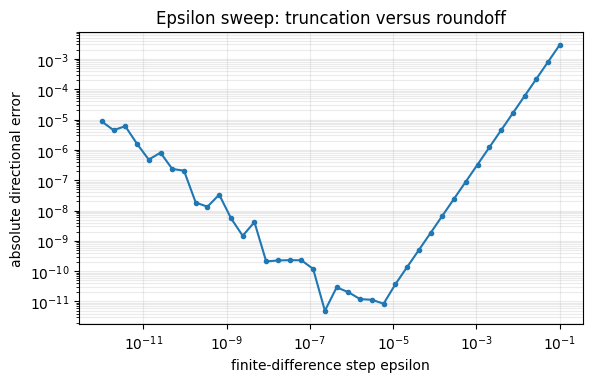

best epsilon in this sweep: 2.2854638641349884e-07


In [94]:
eps_values = torch.logspace(-12, -1, 40)
errors = []
for eps in eps_values:
    fd_eps = (
        objective(theta.detach() + eps * v)
        - objective(theta.detach() - eps * v)
    ) / (2 * eps)
    errors.append(torch.abs(fd_eps - ad).item())

plt.figure(figsize=(6.5, 3.8))
plt.loglog(
    eps_values.numpy(),
    np.array(errors),
    marker='o',
    markersize=3,
)
plt.xlabel('finite-difference step epsilon')
plt.ylabel('absolute directional error')
plt.title('Epsilon sweep: truncation versus roundoff')
plt.grid(True, which='both', alpha=0.25)
plt.show()

best_index = int(np.argmin(errors))
print(
    'best epsilon in this sweep:',
    eps_values[best_index].item(),
)

In [95]:
def stochastic_objective(theta, noise):
    # Common random numbers: the same noise is reused on both sides of the finite difference.
    prediction = nonlinear_renderer(theta) + 0.01 * noise
    target_s = torch.tensor([0.1, -0.2, 0.7])
    return 0.5 * torch.sum((prediction - target_s)**2)

noise = torch.randn(3)
theta_s = torch.tensor([0.4, -0.2], requires_grad=True)
Ls = stochastic_objective(theta_s, noise)
Ls.backward()
gs = theta_s.grad.detach()
v = torch.randn_like(theta_s); v /= torch.linalg.norm(v)
eps = 1e-5
fd_common = (
    stochastic_objective(theta_s.detach() + eps * v, noise)
    - stochastic_objective(theta_s.detach() - eps * v, noise)
) / (2 * eps)
print('common-random-number check error:', torch.abs(fd_common - torch.dot(gs, v)).item())

# Nonsmooth example: ReLU is differentiable almost everywhere but ambiguous at zero.
z = torch.tensor([-1e-6, 0.0, 1e-6], requires_grad=True)
torch.relu(z).sum().backward()
print('ReLU gradients around zero:', z.grad.numpy())


common-random-number check error: 2.4670675224935934e-11
ReLU gradients around zero: [0. 0. 1.]


In [96]:
def scalar_objective(theta):
    return objective(theta)

theta_h = torch.tensor([0.4, -0.2])
v_h = torch.tensor([0.6, -0.8])
# H v = JVP of the gradient function.
grad_fn = grad(scalar_objective)
_, hvp_value = jvp(grad_fn, (theta_h,), (v_h,))
H_full = torch.func.hessian(scalar_objective)(theta_h)
print('Hessian-vector product:', hvp_value.numpy())
assert_close(hvp_value, H_full @ v_h, label='HVP')


Hessian-vector product: [ 1.43226057 -2.18231601]
HVP: PASS (max abs. error=0.000e+00)


In [97]:
# Functional differentiation composes naturally with vectorization.
parameter_batch = torch.tensor([[0.4, -0.2], [0.2, 0.1], [-0.1, 0.3]])
batched_gradients = vmap(grad(scalar_objective))(parameter_batch)
print('batched gradients:\n', batched_gradients.numpy())

# Device-aware code can use the same mathematical functions.
parameter_device = parameter_batch.to(device)
print('batch device:', parameter_device.device)


batched gradients:
 [[ 0.43337346 -0.31344729]
 [-0.05057842  0.28446462]
 [-0.8376191   0.62227087]]
batch device: cpu
